In [1]:
import pandas as pd

df = pd.read_csv("telco_churn_clean.csv")
df.head()

,customer_id,senior_citizen,gender,tenure,contract,payment_method,monthly_charges,total_charges,churn,churn_value
0,3668-QPYBK,0,Male,2,Month-to-month,Mailed check,53.85,108.15,Yes,1
1,9237-HQITU,0,Female,2,Month-to-month,Electronic check,70.70,151.65,Yes,1
2,9305-CDSKC,0,Female,8,Month-to-month,Electronic check,99.65,820.50,Yes,1
3,7892-POOKP,0,Female,28,Month-to-month,Electronic check,104.80,3046.05,Yes,1
4,0280-XJGEX,0,Male,49,Month-to-month,Bank transfer (automatic),103.70,5036.30,Yes,1


In [2]:
df.groupby('churn')['tenure'].mean()

churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

### Insight

Customers who churn tend to have significantly lower tenure, indicating higher risk in early lifecycle stages.

In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      7043 non-null   object 
 1   senior_citizen   7043 non-null   int64  
 2   gender           7043 non-null   object 
 3   tenure           7043 non-null   int64  
 4   contract         7043 non-null   object 
 5   payment_method   7043 non-null   object 
 6   monthly_charges  7043 non-null   float64
 7   total_charges    7032 non-null   float64
 8   churn            7043 non-null   object 
 9   churn_value      7043 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 550.4+ KB


,senior_citizen,tenure,monthly_charges,total_charges,churn_value
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,0.265370
std,0.368612,24.559481,30.090047,2266.771362,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


### Data Overview

The dataset contains customer-level information including demographic attributes, subscription details, and churn indicators.

Initial inspection shows a mix of numerical and categorical variables, suitable for both segmentation and behavioral analysis.

In [4]:
df['churn'].value_counts(normalize=True)

churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

### Insight

The dataset shows the proportion of churned vs retained customers, providing a baseline for evaluating retention performance.

In [5]:
df.groupby('churn')['tenure'].mean()

churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

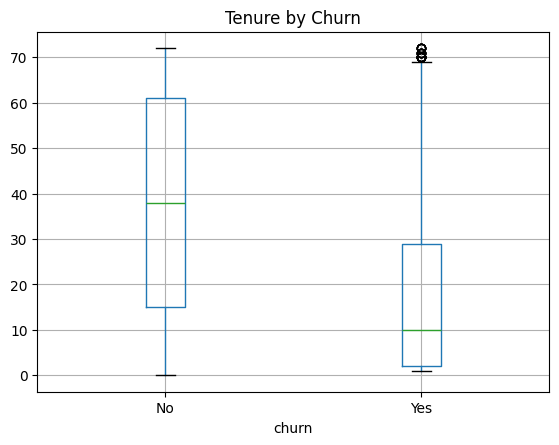

In [6]:
import matplotlib.pyplot as plt

df.boxplot(column='tenure', by='churn')
plt.title("Tenure by Churn")
plt.suptitle("")
plt.show()

### Insight

Customers who churn tend to have significantly lower tenure, confirming that early-stage users are at higher risk of leaving the platform.

In [7]:
df.groupby('churn')['monthly_charges'].mean()

churn
No     61.265124
Yes    74.441332
Name: monthly_charges, dtype: float64

### Insight

Differences in monthly charges between churned and retained customers may indicate pricing sensitivity or perceived value issues.

In [8]:
df.corr(numeric_only=True)

,senior_citizen,tenure,monthly_charges,total_charges,churn_value
senior_citizen,1.000000,0.016567,0.220173,0.102411,0.150889
tenure,0.016567,1.000000,0.247900,0.825880,-0.352229
monthly_charges,0.220173,0.247900,1.000000,0.651065,0.193356
total_charges,0.102411,0.825880,0.651065,1.000000,-0.199484
churn_value,0.150889,-0.352229,0.193356,-0.199484,1.000000


### Insight

Numerical features such as tenure and total charges show relationships with churn, suggesting their relevance in predicting customer behavior.

In [9]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0,6,12,24,100],
    labels=['0-6','6-12','12-24','24+']
)

df.groupby('tenure_group')['churn_value'].mean()

C:\Users\faust\AppData\Local\Temp\ipykernel_13484\3597479673.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tenure_group')['churn_value'].mean()


tenure_group
0-6      0.533333
6-12     0.358865
12-24    0.287109
24+      0.140360
Name: churn_value, dtype: float64

### Insight

Churn is heavily concentrated in the first 6 months, highlighting a critical onboarding period where customer retention efforts should be focused.

In [10]:
# Remove missing values
df = df.dropna()

In [11]:
# Select features for the model
features = ['tenure', 'monthly_charges', 'total_charges', 'senior_citizen']

X = df[features]
y = df['churn_value']

## Model Preparation

We selected key numerical features that are likely to influence customer churn, including tenure, monthly charges, total charges, and demographic indicators.

In [12]:
from sklearn.model_selection import train_test_split

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.linear_model import LogisticRegression

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[940  70]
 [219 178]]
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      1010
           1       0.72      0.45      0.55       397

    accuracy                           0.79      1407
   macro avg       0.76      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



### Model Insight

The model struggles to correctly identify churned customers, capturing only 45% of actual churn cases. This indicates a high number of false negatives, meaning many at-risk customers are not being detected.

### Model Insight

The model shows relatively good precision for churn prediction, meaning that when it flags a customer as high-risk, it is often correct.

### Model Insight

Although the overall accuracy is 79%, this metric is misleading due to class imbalance, as the model performs significantly better on non-churn cases than on churn cases.

### Key Business Insight

The model is better at identifying customers who will stay than those who will churn. From a business perspective, this is a limitation, as the primary goal is to detect and retain at-risk customers.

In [16]:
import pandas as pd

importance = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0]
})

importance.sort_values(by='coefficient', ascending=False)

,feature,coefficient
3,senior_citizen,0.667892
1,monthly_charges,0.026684
2,total_charges,0.000181
0,tenure,-0.069803


### Feature Importance Insight

The model highlights which variables have the strongest influence on churn probability, with tenure typically showing a strong negative relationship with churn.